In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('departments.csv')

In [4]:
df.head()

,department_id,department_name,location,annual_budget,base_wait_days,manual_workload_multiplier,claim_denial_risk,lab_delay_risk
0,D001,Cardiology,Main Campus,2494683.86,3,1.70,0.214,0.200
1,D002,Oncology,East Wing,4388388.17,21,1.79,0.104,0.248
2,D003,Neurology,Main Campus,3995981.05,17,0.98,0.060,0.104
3,D004,Emergency,Satellite Clinic,2112350.96,3,1.38,0.041,0.203
4,D005,Radiology,West Wing,3932157.40,30,1.32,0.169,0.081


In [5]:
print(df.describe())

       annual_budget  base_wait_days  manual_workload_multiplier  \
count   5.000000e+01       50.000000                   50.000000   
mean    3.173501e+06       22.840000                    1.335200   
std     8.755337e+05       13.532063                    0.562974   
min     1.310633e+06        3.000000                    0.710000   
25%     2.511868e+06       11.500000                    0.895000   
50%     3.051075e+06       21.000000                    1.215000   
75%     3.644915e+06       36.750000                    1.610000   
max     5.303691e+06       43.000000                    3.180000   

       claim_denial_risk  lab_delay_risk  
count          50.000000       50.000000  
mean            0.140940        0.154740  
std             0.081961        0.067252  
min             0.040000        0.033000  
25%             0.074500        0.094750  
50%             0.122000        0.173500  
75%             0.199000        0.205750  
max             0.386000        0.249000  


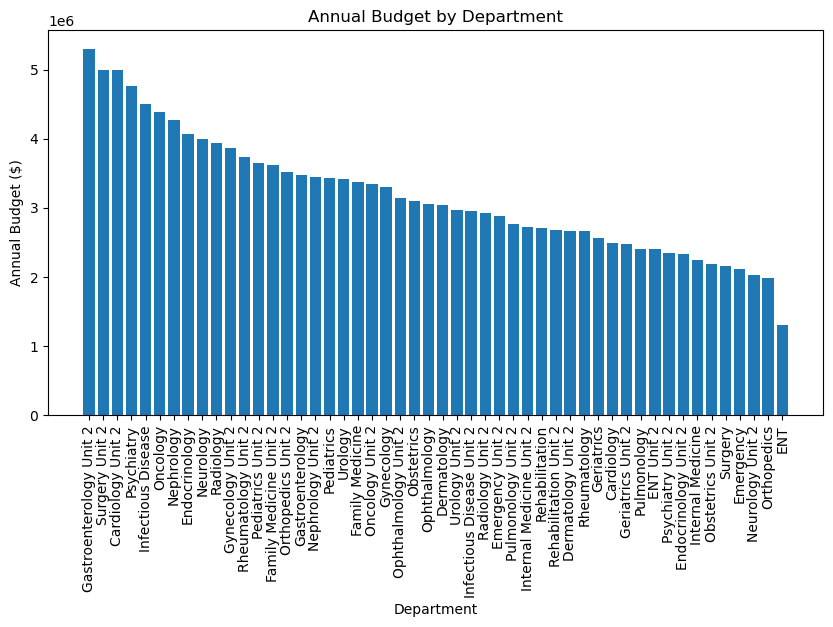

In [6]:
import matplotlib.pyplot as plt

budget = (
    df.sort_values("annual_budget", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(budget["department_name"], budget["annual_budget"])

plt.xticks(rotation=90)
plt.title("Annual Budget by Department")
plt.xlabel("Department")
plt.ylabel("Annual Budget ($)")

plt.show()

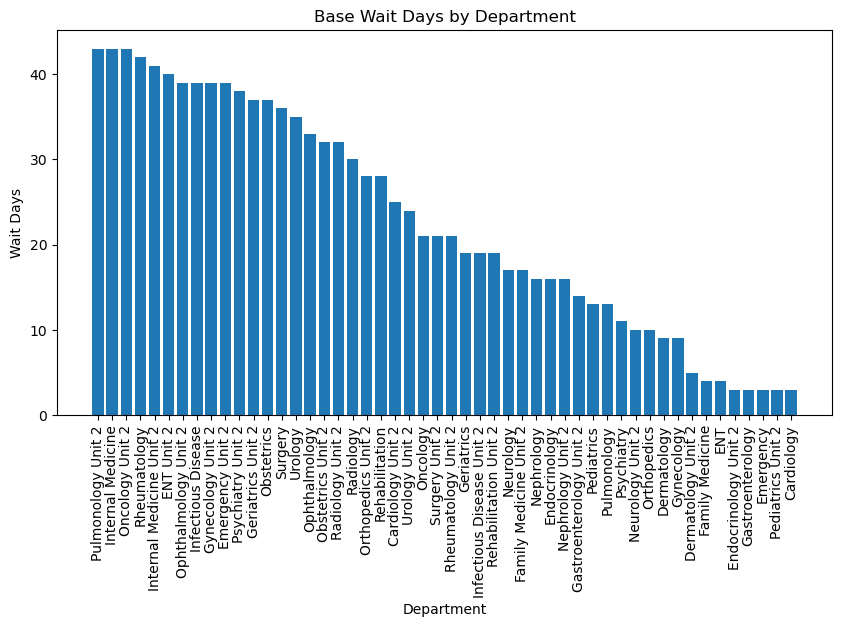

In [7]:
wait = (
    df.sort_values("base_wait_days", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(wait["department_name"], wait["base_wait_days"])

plt.xticks(rotation=90)
plt.title("Base Wait Days by Department")
plt.xlabel("Department")
plt.ylabel("Wait Days")

plt.show()

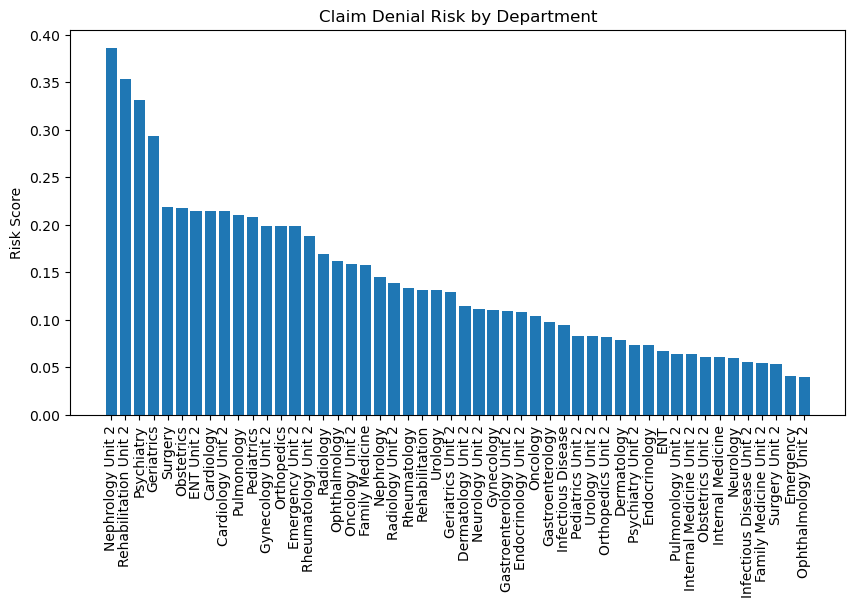

In [8]:
# Claim Denial Risk
risk = (
    df.sort_values("claim_denial_risk", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(risk["department_name"], risk["claim_denial_risk"])

plt.xticks(rotation=90)
plt.title("Claim Denial Risk by Department")
plt.ylabel("Risk Score")

plt.show()

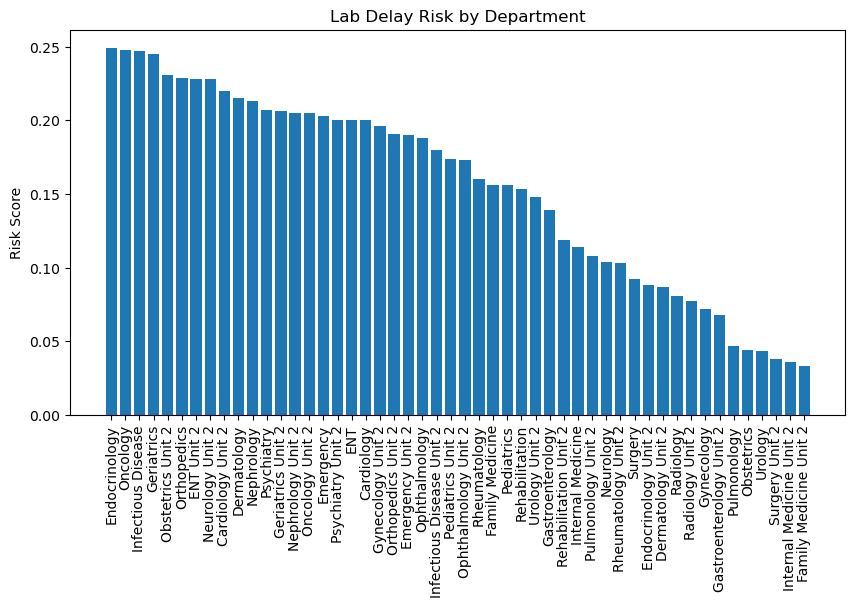

In [9]:
# lab delay risk
lab = (
    df.sort_values("lab_delay_risk", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(lab["department_name"], lab["lab_delay_risk"])

plt.xticks(rotation=90)
plt.title("Lab Delay Risk by Department")
plt.ylabel("Risk Score")

plt.show()

In [10]:
# Correltion analysis 
corr = df[
    [
        "annual_budget",
        "base_wait_days",
        "manual_workload_multiplier",
        "claim_denial_risk",
        "lab_delay_risk"
    ]
].corr()

print(corr)

                            annual_budget  base_wait_days  \
annual_budget                    1.000000       -0.028011   
base_wait_days                  -0.028011        1.000000   
manual_workload_multiplier      -0.124589        0.073995   
claim_denial_risk                0.048703       -0.040987   
lab_delay_risk                  -0.067014       -0.044022   

                            manual_workload_multiplier  claim_denial_risk  \
annual_budget                                -0.124589           0.048703   
base_wait_days                                0.073995          -0.040987   
manual_workload_multiplier                    1.000000          -0.099075   
claim_denial_risk                            -0.099075           1.000000   
lab_delay_risk                                0.064924           0.128262   

                            lab_delay_risk  
annual_budget                    -0.067014  
base_wait_days                   -0.044022  
manual_workload_multiplier        0

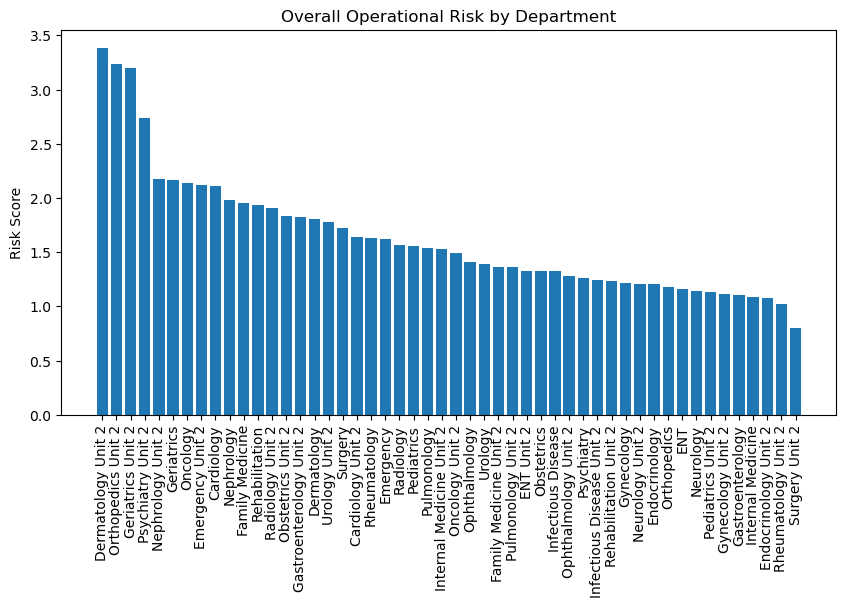

In [12]:
# overall risk score

df["overall_risk"] = (
      df["manual_workload_multiplier"]
    + df["claim_denial_risk"]
    + df["lab_delay_risk"]
)

risk_score = df.sort_values("overall_risk", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(risk_score["department_name"], risk_score["overall_risk"])

plt.xticks(rotation=90)
plt.title("Overall Operational Risk by Department")
plt.ylabel("Risk Score")

plt.show()